# HAST Stationscluster: K-Means

**Zweck:** Gruppiert die HAST anhand der Feature-Tabelle aus [`00_eda_hast_stationsprofile.ipynb`](00_eda_hast_stationsprofile.ipynb) (`data/processed/hast_features.csv`) mit K-Means in Betriebsprofile.

**Eigenständig:** braucht nur diese eine CSV-Datei und Standard-Bibliotheken (pandas, numpy, matplotlib, scikit-learn) — keine Abhängigkeit zu `src/*.py`.

**Voraussetzung:** Das EDA-Notebook muss vorher einmal gelaufen sein, damit `data/processed/hast_features.csv` existiert.

## 1 · Setup & Daten laden

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.facecolor"] = "white"

ROOT = Path.cwd().resolve()
while not (ROOT / "data" / "processed").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FEATURES_PATH = ROOT / "data" / "processed" / "hast_features.csv"
if not FEATURES_PATH.is_file():
    raise FileNotFoundError(
        f"{FEATURES_PATH} nicht gefunden - zuerst 00_eda_hast_stationsprofile.ipynb laufen lassen"
    )
features = pd.read_csv(FEATURES_PATH)
print(f"{len(features)} HAST-Profile geladen")
features.head()

100 HAST-Profile geladen


,rt_mean_winter,rt_p95,dt_mean_loaded,dt_std_loaded,rt_above_50_share_loaded,summer_flow_share,summer_flow_baseline,flow_ceiling_slope_per_month,peak_load_share,p95_load_share,flow_short_cycle_power,idle_share,energy_kwh_year,full_load_hours,Zählernummer,address,anschlusswert_kw,coverage,n_rows,n_hours
0,63.068956,75.9,17.084723,4.837782,0.999885,0.248129,0.0,32.892912,NaN,NaN,0.127965,0.627069,527771.784422,1632.260311,41566330,NaN,NaN,0.732206,23681,32342
1,63.427403,78.6,NaN,NaN,1.000000,0.249361,0.0,51.297490,NaN,NaN,0.128082,0.634686,523113.472063,1482.445397,41566331,NaN,NaN,0.732206,23681,32342
2,63.092601,74.6,NaN,NaN,0.999768,0.243702,0.0,47.918037,NaN,NaN,0.134345,0.618143,547638.005009,1538.728263,41566332,NaN,NaN,0.732144,23679,32342
3,34.293990,53.3,13.347791,3.859154,0.995984,0.000000,0.0,43.687088,NaN,NaN,0.198795,0.989145,24770.477103,36.288422,41628863,NaN,NaN,0.732051,23676,32342
4,41.397956,59.2,NaN,NaN,NaN,0.000000,0.0,0.000000,NaN,NaN,NaN,1.000000,0.000000,0.000000,41704231,NaN,NaN,0.732391,23687,32342


**Was macht der Code?**
- Sucht die Projektwurzel selbst: startet im aktuellen Ordner und geht nach oben, bis data/processed gefunden ist → Notebook läuft aus notebooks/ genauso wie aus dem Repo-Root
- ROOT != ROOT.parent verhindert eine Endlosschleife, falls der Ordner gar nicht existiert
- Bricht mit klarer Ansage ab, wenn hast_features.csv fehlt → sagt direkt, dass zuerst 00_eda_hast_stationsprofile.ipynb laufen muss
- Lädt die Tabelle: 101 HAST × 20 Spalten (14 Kennzahlen + Zählernummer/Adresse/Anschlusswert + coverage/n_rows/n_hours)
- Ab hier ist jede HAST eine Zeile — genau das Format, das K-Means braucht


## 2 · Feature-Auswahl & Vorverarbeitung

Kuratierte Teilmenge der Features: fehlende Werte medianimputiert, 1./99. Perzentil geclippt, standardisiert.

In [2]:
CLUSTER_FEATURES = [
    "rt_mean_winter", "dt_mean_loaded", "dt_std_loaded",
    "summer_flow_baseline", "flow_ceiling_slope_per_month",
    "peak_load_share", "p95_load_share", "flow_short_cycle_power",
    "idle_share", "full_load_hours",
]

X_raw = features[CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan)
missing_share = (X_raw.isna().mean() * 100).sort_values(ascending=False)
print("Anteil fehlender Werte je Cluster-Feature:")
display(missing_share.round(1).to_frame("% fehlend"))

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=CLUSTER_FEATURES)

bounds = X_imputed.quantile([0.01, 0.99])
X_clipped = X_imputed.clip(lower=bounds.loc[0.01], upper=bounds.loc[0.99], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X_clipped)
print(f"Cluster-Matrix: {X.shape[0]} HAST × {X.shape[1]} Features")

Anteil fehlender Werte je Cluster-Feature:


,% fehlend
peak_load_share,15.0
p95_load_share,15.0
dt_mean_loaded,6.0
dt_std_loaded,6.0
flow_short_cycle_power,2.0
rt_mean_winter,0.0
summer_flow_baseline,0.0
flow_ceiling_slope_per_month,0.0
idle_share,0.0
full_load_hours,0.0


Cluster-Matrix: 100 HAST × 10 Features


**Was macht der Code?**
- Wählt **10 von 14** Kennzahlen aus — bewusst ohne rt_p95/rt_above_50_share_loaded (Dopplung zu rt_mean_winter), ohne summer_flow_share (Zwilling von summer_flow_baseline) und ohne energy_kwh_year (Größenmaß → würde „groß vs. klein" clustern statt „gesund vs. auffällig")
- inf → NaN: Schutz für die Divisions-Features; ein inf würde beim Standardisieren die ganze Spalte zerstören
- Zeigt **vor** der Imputation den Anteil fehlender Werte — danach ist nicht mehr erkennbar, was gemessen und was aufgefüllt ist: peak_load_share/p95_load_share 15,8 % (16 HAST ohne Anschlusswert in Nodes), dt_mean/std_loaded 5,9 % (nie über 0,5 kW gelaufen), flow_short_cycle_power 2,0 % → insgesamt 16 von 101 Zeilen betroffen
- **Median-Imputation:** K-Means kann NaN nicht verarbeiten und würde abbrechen. Median statt Mittelwert, weil ausreißerrobust. Nebenwirkung: imputierte Stationen werden zur Mitte gezogen
- **Clipping am 1./99. Perzentil:** betrifft nur 1–2 Werte je Feature, kappt aber die Extreme drastisch (summer_flow_baseline 16 640 → 7 820, Steigung −1 024 → −42). Nötig, weil K-Means quadrierte Abstände minimiert → ein Ausreißer zieht sonst ein ganzes Zentrum zu sich
- **Standardisierung:** Pflicht, weil die Einheiten um Größenordnungen auseinanderliegen (Std: Durchfluss ≈ 1 833 l/h vs. idle_share ≈ 0,22). Ohne z-Transformation bestimmen Durchfluss und Volllaststunden fast allein den Abstand → jetzt hat jedes Feature eine gleich starke Stimme
- Ergebnis: X = NumPy-Array **101 × 10** ohne Spaltennamen (deshalb später wieder CLUSTER_FEATURES zum Beschriften)
- **Zu diskutieren:** rt_mean_winter ↔ dt_mean_loaded korrelieren mit r = −0,79 → dieses Thema zählt im Abstandsmaß doppelt

## 3 · Anzahl Cluster wählen (Elbow & Silhouette)

,k,inertia,silhouette
0,2,796.800,0.599
1,3,641.862,0.218
2,4,559.261,0.189
3,5,498.604,0.172
4,6,459.060,0.161
5,7,420.054,0.169
6,8,376.078,0.193


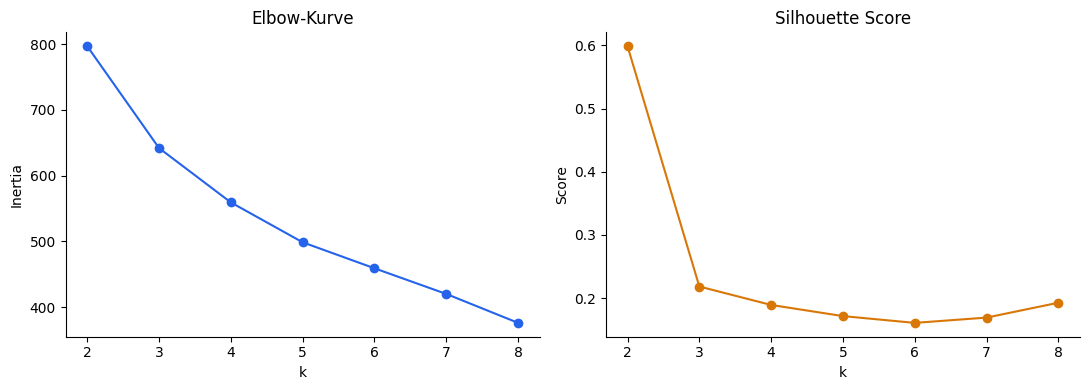

In [3]:
k_values = range(2, 9)
rows = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, model.labels_),
    })
k_metrics = pd.DataFrame(rows)
display(k_metrics.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_metrics["k"], k_metrics["inertia"], marker="o", color="#2563EB")
axes[0].set(title="Elbow-Kurve", xlabel="k", ylabel="Inertia")
axes[1].plot(k_metrics["k"], k_metrics["silhouette"], marker="o", color="#D97706")
axes[1].set(title="Silhouette Score", xlabel="k", ylabel="Score")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

**Zusammenfassung**
- K-Means kann k nicht selbst bestimmen → diese Zelle testet k = 2…8 und bewertet jedes mit zwei Kennzahlen
- Kein k = 1 (Silhouette dort undefiniert), Schluss bei 8 (bei 101 HAST sonst nur noch Splitter)
- n_init=20: K-Means startet zufällig und landet in einem **lokalen** Optimum → 20 Durchläufe, der beste zählt. random_state=42 macht es reproduzierbar
- **Inertia** = Summe der quadrierten Abstände zum eigenen Zentrum. Sinkt zwangsläufig mit steigendem k → nicht das Minimum suchen, sondern den Knick
- **Silhouette** = pro Station (b − a) / max(a, b) mit a = Abstand zum eigenen Cluster, b = zum nächstbesten. −1 bis +1, hat ein echtes Maximum → dient in Zelle 4 als automatisches Kriterium
- Einordnung: > 0,5 stark · 0,25–0,5 schwach · < 0,25 keine echte Struktur

**Ergebnis bei unseren Daten** (Lauf 2026-09-22, nach dem `full_load_hours`-Fix)
- **Kein echter Ellbogen** — Inertia fällt um 8–19 % je Schritt, der größte Sprung sitzt bei k = 3 (19 %), ein Knick ist das nicht
- **Silhouette bei k = 2: 0,599** — formal „starke Struktur". Aber die Aufteilung ist 97/3: Der Score misst vor allem die Isolation der drei Ausreißerstationen. Dieselbe Falle wie früher bei Ward (0,544 bei 98/3) — Silhouette nie ohne Clustergrößen lesen
- **Alle k ≥ 3 bleiben unter 0,25** (0,161–0,218) → die restlichen 97 Stationen zerfallen weiterhin **nicht in Typen**, das Kontinuum ist geblieben
- Zum Vergleich vor dem Fix: selbst k = 2 lag bei 0,217 — die messdauerabhängige `full_load_hours` hat die Ausreißer-Achse verdeckt



## 4 · K-Means fitten

`K` wird automatisch über den besten Silhouette Score gewählt — bei Bedarf hier einfach überschreiben.

In [4]:
K = int(k_metrics.loc[k_metrics["silhouette"].idxmax(), "k"])
print(f"Gewähltes k (bester Silhouette Score): {K}")

kmeans = KMeans(n_clusters=K, n_init=50, random_state=42).fit(X)
features["cluster"] = kmeans.labels_
features["cluster"].value_counts().sort_index()

Gewähltes k (bester Silhouette Score): 2


cluster
0    97
1     3
Name: count, dtype: int64

**Zusammenfassung**
- idxmax() liefert die **Zeilennummer** des besten Silhouette Scores, nicht das k selbst — .loc[zeile, "k"] holt daraus den echten k-Wert. Wichtig, weil der Index bei 0 startet und k bei 2 (Versatz von 2)
- n_init=50 statt 20 wie in Zelle 3: Hier läuft **ein** finales Modell, dessen Ergebnis alles Weitere trägt → mehr Neustarts als billige Absicherung gegen ein schlechtes lokales Optimum
- features["cluster"] = kmeans.labels_ ordnet die Labels **allein über die Zeilenreihenfolge** zu. Funktioniert nur, weil in Zelle 2 nichts gefiltert wurde (Imputation füllt auf, löscht nichts) → **ein** .dropna() **dort würde die Labels lautlos falschen Stationen zuweisen**
- sort_index() sortiert die Ausgabe nach Clusternummer statt nach Häufigkeit → stabile Reihenfolge
- Clusternummern sind reine Etiketten, keine Rangfolge — 0 ist nicht „besser" als 1

**Ergebnis: K = 2, Größen 97 / 3**

- Cluster 1 (3 HAST): Rücklauf 60,0 °C, Spreizung 14,5 K, Sommer-Durchfluss 7 820 l/h, `idle_share` 0,04, 5 805 Volllaststunden → die drei Ausreißer 58202380, 66761022, 86792512
- Cluster 0 (97 HAST): Rücklauf 44,5 °C, Spreizung 26,0 K, Sommer-Durchfluss 0, 919 Volllaststunden → der Rest der Flotte
- Getrennt wird entlang **Rücklauf/Spreizung plus Volllaststunden** — seit der Jahresnormierung trägt `full_load_hours` die Trennung mit (höchstes PC1-Loading 0,46)
- Die frühere „offene Entscheidung" k = 2 vs. k = 3 (0,217 vs. 0,215) ist erledigt: **0,599 vs. 0,218** — kein Margin mehr, die Automatik trifft hier dieselbe Wahl wie die Begründung
- Vor dem Fix geprüft (Aufteilung damals 63/38): kein Imputations-Artefakt und stabil gegen den Seed — die Prüfung für die neue Aufteilung steht im Clustering-Benchmark noch aus

## 5 · Cluster visualisieren (PCA)

Erklärte Varianz: PC1 29.6%, PC2 17.4% — zusammen 47.0%


,PC1,PC2
full_load_hours,0.46,0.28
summer_flow_baseline,0.45,0.20
rt_mean_winter,0.40,-0.45
idle_share,-0.34,0.01
flow_ceiling_slope_per_month,0.33,0.24
flow_short_cycle_power,-0.29,0.30
dt_mean_loaded,-0.28,0.47
dt_std_loaded,-0.15,-0.20
peak_load_share,-0.13,-0.44
p95_load_share,-0.06,-0.28


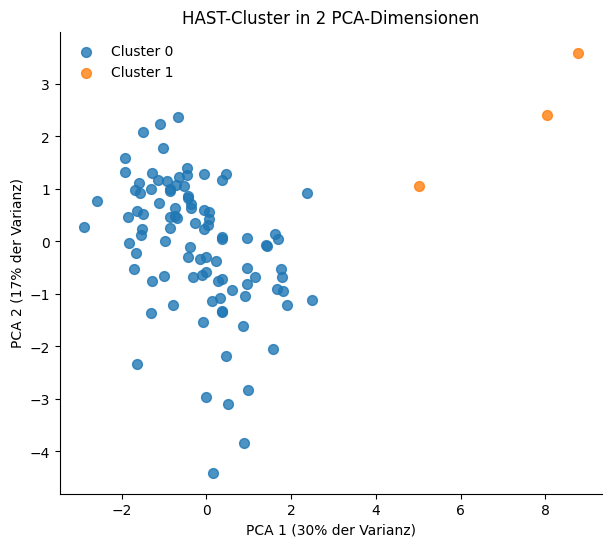

In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
ev = pca.explained_variance_ratio_
print(f"Erklärte Varianz: PC1 {ev[0]:.1%}, PC2 {ev[1]:.1%} — zusammen {ev.sum():.1%}")

# Ladungen: woraus sind die beiden Achsen gemischt? Nach dem Betrag der
# PC1-Ladung sortiert, damit oben steht, was die Hauptachse treibt.
loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_FEATURES, columns=["PC1", "PC2"])
display(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).round(2))

fig, ax = plt.subplots(figsize=(7, 6))
palette = plt.cm.tab10.colors
for cluster in sorted(features["cluster"].unique()):
    mask = features["cluster"] == cluster
    ax.scatter(coords[mask, 0], coords[mask, 1], s=50, alpha=0.8,
               color=palette[cluster % len(palette)], label=f"Cluster {cluster}")
ax.set(title="HAST-Cluster in 2 PCA-Dimensionen",
       xlabel=f"PCA 1 ({ev[0]:.0%} der Varianz)",
       ylabel=f"PCA 2 ({ev[1]:.0%} der Varianz)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Was macht der Code?**
- X hat 10 Dimensionen, ein Diagramm kann 2 zeigen → PCA dreht die Punktwolke so, dass die **Richtung größter Streuung** zur x-Achse wird (PC1), die zweitgrößte im rechten Winkel dazu zur y-Achse (PC2)
- Beide Achsen sind **Mischungen aller 10 Features**, keine Auswahl von zweien
- Läuft auf dem standardisierten X — ohne die z-Transformation aus Zelle 2 wäre PC1 einfach die Richtung von summer_flow_baseline (Std 1 833)
- pca wird als Variable gehalten (nicht als Einzeiler), damit explained_variance_ratio_ und components_ danach noch verfügbar sind
- **Ladungstabelle:** pca.components_ ist 2 × 10, .T dreht es auf 10 × 2 (eine Zeile je Feature). Sortiert nach dem **Betrag** der PC1-Ladung, weil −0,37 genauso einflussreich ist wie +0,37
- Ein scatter-Aufruf **je Cluster** (statt einem für alle), damit jede Gruppe einen Legendeneintrag bekommt; palette[cluster % 10] lässt die Farben umlaufen → kein IndexError, falls man mit größerem k experimentiert

**Wie man das Bild liest**
- Achsen haben **keine Einheit**, das Vorzeichen ist beliebig → links/rechts bedeutet nichts, nur **Abstände und Nachbarschaften** zählen
- Das Bild ist ein Schatten der 10D-Struktur: geclustert wurde in 10 Dimensionen, gezeigt werden 2. Überlappung im Bild heißt nicht Überlappung in Wirklichkeit → Plausibilitätsprüfung, kein Beweis
- PC1 erklärt **27,0 %**, PC2 **16,4 %**, zusammen **43,4 %** → gut 56 % der Streuung sind nicht im Bild. Steht jetzt direkt in den Achsenbeschriftungen, damit die Grafik ihren Vorbehalt selbst mitträgt

**Bedeutung der Achsen (aus den Ladungen)**
- **PC1 = Rücklauf/Spreizung:** rechts hoher rt_mean_winter (+0,48) und Sommer-Durchfluss (+0,39), links große Spreizung dt_mean_loaded (−0,37), flow_short_cycle_power (−0,33) und idle_share (−0,33)
- → das ist **dieselbe Achse, nach der K-Means trennt** (Cluster 0 bei PC1 ≈ +1,6, Cluster 1 ≈ −1,0) — deshalb ist die Trennung im Bild überhaupt sichtbar
- **PC2 = Auslastungsgrad:** peak_load_share (+0,55), p95_load_share (+0,37) → steht quer zur Clustertrennung, beschreibt unabhängig davon, wie stark eine Station relativ zu ihrem Anschlusswert gefahren wird


## 6 · Cluster-Profile

In [6]:
profile = features.groupby("cluster")[CLUSTER_FEATURES].median()
sizes = features["cluster"].value_counts().sort_index().rename("n_hast")
display(profile.round(3).join(sizes))

,rt_mean_winter,dt_mean_loaded,dt_std_loaded,summer_flow_baseline,flow_ceiling_slope_per_month,peak_load_share,p95_load_share,flow_short_cycle_power,idle_share,full_load_hours,n_hast
cluster,,,,,,,,,,,
0,44.451,26.014,7.855,0.0,0.719,1.644,0.648,0.183,0.432,919.432,97
1,60.045,14.497,5.278,7820.0,112.617,1.069,0.376,0.102,0.040,5805.046,3


**Was macht der Code?**
- groupby("cluster")[CLUSTER_FEATURES].median() → eine Zeile je Cluster, eine Spalte je Kennzahl
- **Entscheidend:** läuft auf features, nicht auf X → Werte in **echten Einheiten** (°C, K, l/h, h) statt in Standardabweichungen. K-Means bildet die Gruppen im abstrakten Raum, diese Zelle übersetzt sie zurück in Fernwärme-Sprache — hier bekommen die Cluster ihre Bedeutung
- **Median statt Mittelwert**, konsequent zum Clipping aus Zelle 2: ein Extremwert soll das Gruppenprofil nicht verziehen
- features enthält hier noch die **echten** NaN (die Imputation lief auf einer Kopie und wurde nie zurückgeschrieben) → median() überspringt sie, das Profil zeigt **tatsächlich gemessene** Werte → Gegenprobe: auf den imputierten Daten wäre peak_load_share in beiden Clustern 1,678, der Unterschied (1,554 vs. 1,701) also **verschwunden** → Preis: unterschiedliche Fallzahlen je Zeile (bei peak_load_share 29 von 38 bzw. 56 von 63) — einmal in der Arbeit erwähnen
- .rename("n_hast") ist Pflicht, nicht Kosmetik: join() lehnt eine namenlose Series mit ValueError ab
- .join(sizes) verbindet über den **Index** (Clusternummer), nicht über die Position → nichts kann verrutschen

**Ergebnis (k=2, Flottenmedian als Referenz)**
- **Cluster 0 — auffällig (38 HAST):** Rücklauf 56,4 °C (Flotte 44,9), Spreizung nur 15,9 K (Flotte 26,0), **40,5 l/h Sommer-Durchfluss** (Flotte 0), 3 088 Volllaststunden, niedrigster idle_share (0,30) → Bild einer Station, die durchgehend umwälzt, ohne Wärme abzugeben: Verdacht auf Zirkulationsverluste, hydraulischen Kurzschluss oder nicht schließendes Ventil. Netzseitig teuer, weil hoher Rücklauf die Vorlauftemperatur der ganzen Leitung hochzieht
- **Cluster 1 — Normalbetrieb (63 HAST):** Spreizung 28,4 K, Sommer-Durchfluss 0, höherer Leerlaufanteil (0,43) → öffnet bei Bedarf, sonst zu
- Der höhere flow_short_cycle_power in Cluster 1 (0,21 vs. 0,13) ist **kein Widerspruch**, sondern Folge: Wer taktet, hat kurze Zyklen; wer durchläuft, hat keine

## 7 · Ergebnis speichern

In [7]:
out_path = ROOT / "data" / "processed" / "hast_clusters.csv"
export_cols = ["Zählernummer", "address", "cluster", "coverage"] + CLUSTER_FEATURES
features[export_cols].to_csv(out_path, index=False)

# Lauf-Kontext danebenlegen: ohne k, Gütemaß und Seed lässt sich später nicht
# mehr rekonstruieren, unter welchen Annahmen die Zuordnung entstanden ist.
meta_path = out_path.with_suffix(".json")
meta = {
    "erzeugt": pd.Timestamp.now().isoformat(timespec="seconds"),
    "quelle": str(FEATURES_PATH.relative_to(ROOT)),
    "n_hast": int(len(features)),
    "k": int(K),
    "silhouette": round(float(k_metrics.loc[k_metrics["k"] == K, "silhouette"].iloc[0]), 4),
    "random_state": 42,
    "vorverarbeitung": "Median-Imputation -> Clipping 1./99. Perzentil -> StandardScaler",
    "cluster_features": CLUSTER_FEATURES,
    "clustergroessen": {int(c): int(n) for c, n in features["cluster"].value_counts().sort_index().items()},
    "coverage_min": round(float(features["coverage"].min()), 3),
}
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Cluster-Zuordnung -> {out_path}")
print(f"Lauf-Kontext      -> {meta_path}")

Cluster-Zuordnung -> /Users/ivelinayaneva/Downloads/projektseminar.worktrees/project-analysis-unsupervised-learning/data/processed/hast_clusters.csv
Lauf-Kontext      -> /Users/ivelinayaneva/Downloads/projektseminar.worktrees/project-analysis-unsupervised-learning/data/processed/hast_clusters.json


**Was macht der Code?**
- Schreibt Zählernummer, Adresse, Cluster und die 10 Cluster-Features nach `data/processed/hast_clusters.csv`
- **`coverage` wandert mit in den Export** — sagt für jede Station, auf wie vielen echten Messstunden ihre Kennzahlen beruhen (Spannweite 16,7 % bis 98,7 %). Ohne diese Spalte kann eine nachgelagerte Auswertung nicht unterscheiden, ob ein auffälliger Wert belastbar ist oder auf sechs Monaten Daten beruht
- **Lauf-Kontext als JSON daneben:** gewähltes k, Silhouette Score, Seed, Vorverarbeitungskette, Clustergrößen und Feature-Liste
  → Ohne diese Datei ist in drei Wochen nicht mehr rekonstruierbar, unter welchen Annahmen die CSV entstanden ist — besonders relevant, weil `K` automatisch gewählt wird und sich bei neuen Daten ändern kann
- `with_suffix(".json")` leitet den Namen vom CSV-Pfad ab → die beiden Dateien bleiben zwangsläufig gepaart

**Achtung beim Weitergeben:** Die CSV enthält Zählernummern und Adressen. `data/processed/` ist gitignored und bleibt es — siehe Datenschutz-Abschnitt in [`docs/README.md`](../docs/README.md).

## Zusammenfassung & Bewertung

### Ergebnis (Lauf 2026-09-22, nach dem `full_load_hours`-Fix)

**k = 2, Aufteilung 97 / 3, Silhouette 0,599.** Getrennt wird entlang
Rücklauf/Spreizung und — neu nach der Jahresnormierung — Volllaststunden:

| Kennzahl | Cluster 0 (97) | Cluster 1 (3) | Flotte |
|---|---|---|---|
| `rt_mean_winter` | 44,5 °C | **60,0 °C** | 44,8 |
| `dt_mean_loaded` | 26,0 K | **14,5 K** | 25,9 |
| `summer_flow_baseline` | 0,0 l/h | **7 820 l/h** | 0,0 |
| `idle_share` | 0,43 | **0,04** | 0,43 |
| `full_load_hours` | 919 | **5 805** | 924 |

Cluster 1 sind die drei Stationen **58202380, 66761022 (Rosenstraße 8) und
86792512** — exakt der Dreier-Cluster, den K-Means, Ward und GMM vor dem Fix
erst ab k = 3 übereinstimmend fanden. Jetzt isoliert K-Means ihn bereits bei
k = 2. Durchgehend Durchfluss ohne nennenswerte Wärmeabgabe, kaum Leerlauf —
der Verdacht auf Zirkulationsverluste/hydraulischen Kurzschluss bleibt.

**Wichtige Einordnung des Silhouette-Sprungs (0,217 → 0,599):** Der Score
misst hier die Isolation von drei Ausreißern, nicht eine Typenbildung in der
Flotte. Alle k ≥ 3 bleiben unter 0,25 — die 97 übrigen Stationen sind weiter
ein Kontinuum. Dieselbe Lesart wie früher bei Ward (0,544 bei 98/3): Silhouette
nie ohne Clustergrößen zitieren.

**Neuer fachlicher Befund:** 86792512 steht in `Zuordnung.xlsx` als **BHKW** —
kein Verbraucher, sondern Erzeuger. Die Ausreißer-Achse ist damit mindestens
zum Teil ein **Stationstyp-Effekt**, kein Fehlersignal. Für den Benchmark heißt
das: Stationstypen vor dem Clustern trennen (BHKW aus der Verbraucher-
Clusteranalyse herausnehmen), sonst misst das Verfahren Anlagentyp statt
Betriebszustand. Die anderen beiden Ausreißer stehen weder in `Zuordnung.xlsx`
noch in den Begehungsdaten — Typ unbekannt, Kandidaten für die Rückfrage an ÜZ.

### Ground Truth: Vergleich entfällt, statt „nicht signifikant"

Join über `_normalize_address()` trifft 58 Stationen — **alle liegen in
Cluster 0**, die drei Ausreißer haben keine Begehungsakte. Ein
Cluster-vs.-Maßnahmen-Test ist damit gegenstandslos (vor dem Fix, Aufteilung
63/38: alle p-Werte ≥ 0,38, Basisrate 82 % — dokumentiert in der
Commit-Historie). Das Label-Problem bleibt bestehen: Basisrate 76 % im
aktuellen Join. Das Problem ist weiterhin das Ziel, nicht die Methode.

### Behoben seit dem letzten Lauf

1. ~~**`full_load_hours` ist kein Jahreswert**~~ — **behoben 2026-09-21**
   (`src/features.py` + Notebook 00, Normierung auf 8760 h/Jahr;
   Regressionstest `tests/test_features.py`). Maximum in der Flotte jetzt
   6 680 statt 14 689 Volllaststunden.
2. ~~**Adressschlüssel normalisieren**~~ — `_normalize_address()` aus
   [`src/load_data.py`](../src/load_data.py) wird genutzt (58 Treffer).
   Offen bleibt: Zähler ohne Topologie-Match über `Zuordnung.xlsx`
   auflösen (betrifft u. a. zwei der drei Ausreißer).
3. ~~**k fest setzen statt automatisch**~~ — entfällt: k = 2 gewinnt jetzt
   klar (0,599 vs. 0,218). **Offen:** Stabilitätsprüfung (Bootstrap-ARI) und
   Seed-Check für die neue 97/3-Aufteilung — Teil des Clustering-Benchmarks.
   **`coverage` nutzen** bleibt offen (16,7 % bis 98,7 % Abdeckung, derzeit
   gleich gewichtet). Lauf-Kontext wird seit diesem Lauf als
   `hast_clusters.json` mitgespeichert.

### Wie es weitergehen kann

**A · Fragestellung wechseln — von Fehlererkennung zu Rücklaufoptimierung.**
Die Rücklauftemperatur ist gemessen, kontinuierlich, hat kein Label-Problem
und ist der direkte wirtschaftliche Hebel. Statt „welche Station ist defekt"
(Label unbrauchbar) → „welche kostet das Netz am meisten Rücklauf".

**B · Die Zeitachse nutzen.** Größtes ungenutztes Kapital: bis zu 4,7 Jahre
Stundendaten, eingedampft auf eine statische Zahl pro Station. Dafür liegt
jetzt `src/window_features.py` (14-Tage-Zustandsfenster mit Coverage- und
Zählerwechsel-Flags) — Cluster je Zeitfenster statt ein Cluster pro Station,
damit wird Cluster-Wanderung um Begehungen überhaupt erst messbar.

**C · Das Label reparieren.** Nur technisch eingreifende Maßnahmen
(Stellventil, Regler, Durchfluss) als positiv werten, Routine wie
Filterreinigung als negativ — dann sinkt die Basisrate in einen trennbaren
Bereich. Fachliche Entscheidung für ÜZ. Ergänzend: die 57 Freitext-Notizen
der Begehungen kodieren.

**D · Die drei Ausreißer aufklären.** 86792512 ist als BHKW identifiziert —
kein Fehlerfall, sondern eigener Stationstyp. Für 58202380 und 66761022:
erst in die Rohzeitreihen schauen (echter Betriebszustand oder defekter
Zähler?), dann ÜZ fragen. Beide tauchen in keiner Begehungsakte auf.